Added SNR estimate as 4th output channel

Also training on more difficult data: 
- d0.00-0.80
- added +/- 5 deg rotation to pipette
- more background noise


**Performance:** 

**Model:**
ImageNet1k_v2
- training resnet [-2][-2:] and [-1]
- adaptive avg pooling layer
- one dense layer with xyzw output

**Training:**
- Batch size 96
- MSE loss
- Adam, learning rate 0.001


In [18]:
import numpy as np
from training_data import load_training_data
import matplotlib.pyplot as plt

In [2]:
save_path = "torch_models/04_more_increased_difficulty.pth"
training_data_path = "training_data"

In [ ]:
all_training_data = load_training_data(training_data_path)
levels = list(all_training_data.levels.keys())
all_training_data.levels = {level: all_training_data.levels[level] for level in levels[:]}
print(all_training_data.levels)

In [ ]:
levels = list(all_training_data.levels.keys())
rows = 5
shape = (rows, len(levels))

fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

for j in range(shape[1]):
    difficulty = levels[j]
    ax[0,j].set_title(f"difficulty={difficulty}")
    images, pos = all_training_data.get_level(difficulty)[:rows].get_arrays()
    for i in range(shape[0]):
        ax[i,j].imshow(images[i], cmap='gray')
        ax[i,j].scatter(pos[i, 2], pos[i, 1], color='red')
        ax[i,j].set_xlabel(f"z={pos[i, 0]:0.2f} snr={pos[i, 3]:.4g}")

In [ ]:
# import and test torch

import torch
print("CUDA:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [6]:
from torch_model_04 import PipetteDetector, make_image_tensor, make_position_tensor, pos_normalizer

In [ ]:
# initialize a model just to see its structure
from torchsummary import summary
test_model = PipetteDetector()
test_model.to(device);
# print(model)
summary(test_model, input_size=(3, 400, 400))

del test_model
torch.cuda.empty_cache()


In [8]:

batch_size = 96
# data_generator = training_data.generator(batch_size)
# data_generator yields batches of (image, position) data
#  - images are 3D numpy arrays of shape (batch_size, height, width), with values in [0, 255]
#  - positions are 2D numpy arrays of shape (batch_size, (z, y, x)), with z values in microns and x, y in pixels 

# split the data into training and validation sets
validation_size = 400
training_data, validation_data = all_training_data.split([
    1 - validation_size / len(all_training_data), 
    validation_size / len(all_training_data)
])
v_img, v_pos = validation_data.get_arrays()
validation_images = make_image_tensor(v_img)
validation_positions = make_position_tensor(v_pos)

In [9]:
import torch.nn as nn
import torch.optim as optim

# initialize the model
model = PipetteDetector()
model.to(device)

# Define a loss function and optimizer
criterion = nn.MSELoss()  # for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)
# scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

In [10]:

class TrainingHistory:
    def __init__(self):
        self.history = {'i': [], 'loss': []}

    def append(self, i, prediction, target, loss):
        self.history['i'].append(i)
        self.history['loss'].append(loss)
        result = TrainingHistory.analyze_prediction(prediction, target)
        for k,v in result.items():
            if k not in self.history:
                self.history[k] = []
            self.history[k].append(v)

    def __getitem__(self, key):
        return np.array(self.history[key])
    
    def plot(self, loss_ax, accuracy_ax, label=None):
        alpha = 1.0 if 'validat' in label else 0.5
        loss_ax.plot(self.history['i'], self.history['rmse_xy'], label=label+' xy RMSE', color=(0, 0.7, 0), alpha=alpha)
        loss_ax.plot(self.history['i'], self.history['rmse_z'], label=label+' z RMSE', color=(0.7, 0, 0), alpha=alpha)
        loss_ax.plot(self.history['i'], self.history['rmse_snr'], label=label+' snr RMSE', color=(0, 0, 0.7), alpha=alpha)
        loss_ax.set_yscale('log')
        loss_ax.legend()
        accuracy_ax.plot(self.history['i'], self.history['accuracy_xy'], label=label+' xy accuracy', color=(0, 0.7, 0), alpha=alpha)
        accuracy_ax.plot(self.history['i'], self.history['accuracy_z'], label=label+' z accuracy', color=(0.7, 0, 0), alpha=alpha)
        accuracy_ax.set_ylim(0, 1)
        accuracy_ax.legend()

    @staticmethod
    def analyze_prediction(predicted_pos, target_pos, radius=0.02):
        predicted_pos = predicted_pos.cpu().detach().clone().numpy()
        target_pos = target_pos.cpu().detach().clone().numpy()
        predicted_z_sign = np.sign(predicted_pos[:, 0])
        target_z_sign = np.sign(target_pos[:, 0])
        result = {
            'rmse_xy': ((predicted_pos - target_pos)[:, 1:3]**2).mean()**0.5,
            'rmse_z': ((predicted_pos - target_pos)[:, 0]**2).mean()**0.5,
            'rmse_snr': ((predicted_pos - target_pos)[:, 3]**2).mean()**0.5,
            'n_correct_xy': (((predicted_pos - target_pos)[:, 1:3]**2).sum(axis=1)**0.5 < radius).sum(),
            'n_correct_z': (predicted_z_sign == target_z_sign).sum(),
            'batch_size': predicted_pos.shape[0],
        }
        result['accuracy_xy'] = result['n_correct_xy'] / result['batch_size']
        result['accuracy_z'] = result['n_correct_z'] / result['batch_size']
        return result


## Train the model

In [11]:
training_history = TrainingHistory()
validation_history = TrainingHistory()
iterations = 0
data_generator = training_data.generator(batch_size)

In [ ]:
try:
    model.train()  # set model to training mode
    for data in data_generator:
        # inputs is a 4D numpy array of shape (batch_size, height, width, channels), normalized to [0, 1]
        # labels is a 2D numpy array of shape (batch_size, 3), normalized using training_data.output_norm
        inputs, labels = data
        image_tensor = make_image_tensor(inputs)
        position_tensor = make_position_tensor(labels)

        # zero the parameter gradients (otherwise they accumulate)
        optimizer.zero_grad()

        # run model, calculate loss, and backpropagate
        output = model(image_tensor)
        loss = criterion(output, position_tensor)
        loss.backward()
        optimizer.step()
        # scheduler.step()

        # track performance over time
        training_history.append(iterations, output, position_tensor, loss.item())
        del image_tensor, position_tensor, output, loss
        torch.cuda.empty_cache()

        if iterations % 10 == 9:
            with torch.no_grad():
                val_output = model(validation_images)
                val_loss = criterion(val_output, validation_positions)
                validation_history.append(iterations, val_output, validation_positions, val_loss.item())

            recent_size = 10
            training_loss = training_history['loss'][-recent_size:]
            training_accuracy = training_history['accuracy_xy'][-recent_size:].mean()
            val_loss = validation_history['loss'][-1]
            validation_accuracy = validation_history['accuracy_xy'][-1]
            validation_z_accuracy = validation_history['accuracy_z'][-1]
            print(
                f'[step {iterations:06d}] avg sqrt loss: {(training_loss**0.5).mean():0.6f}\n'
                f'              final sqrt loss: {training_loss[-1]**0.5:0.6f}\n'
                f'              val sqrt loss: {val_loss**0.5:0.6f}\n'
                f'              val xy rmse: {validation_history["rmse_xy"][-1]:0.6f}\n'
                f'              val z rmse: {validation_history["rmse_z"][-1]:0.6f}\n'
                f'              val snr rmse: {validation_history["rmse_snr"][-1]:0.6f}\n'
                f'              training xy accuracy: {100 * training_accuracy:0.2f}%\n'
                f'              validation xy accuracy: {100 * validation_accuracy:0.2f}%\n'
                f'              validation z accuracy: {100 * validation_z_accuracy:0.2f}%\n'
            )
            del val_output, val_loss
            torch.cuda.empty_cache()
            
        if iterations % 100 == 99:
            print("Saving model..")
            torch.save(model.state_dict(), save_path)

        iterations += 1

except KeyboardInterrupt:
    print('Interrupted, saving..')
    torch.save(model.state_dict(), save_path)
    optimizer_path = save_path.replace('.pth', '_optimizer.pth')
    torch.save(optimizer.state_dict(), optimizer_path)

print('Finished Training')

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax[0].grid(True)
ax[1].grid(True)
training_history.plot(ax[0], ax[1], label='training')
validation_history.plot(ax[0], ax[1], label='validation')


In [ ]:
# reload model weights
model.load_state_dict(torch.load(save_path))

## Check against training data

In [ ]:
shape = (10, len(training_data.levels))
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))
for i,level in enumerate(training_data.levels):
    ax[0, i].set_title(level)


n_examples = 100
predictions = {}
for col,level in enumerate(training_data.levels):
    training_level = training_data.get_level(level)
    image, pip_pos = training_level[:n_examples].get_arrays()
    # inds = np.arange(len(image))
    # np.random.shuffle(inds)
    # image = image[inds]
    # pip_pos = pip_pos[inds]

    # pip_pos = training_data.output_norm.denormalize(pip_pos)
    # use model in inference mode to make prediction from image
    model.eval()  # set model to inference mode
    with torch.no_grad():
        image_tensor = make_image_tensor(image)
        pred = model(image_tensor).cpu().numpy()
        pred = pos_normalizer.denormalize(pred)
    
    predictions[level] = {'image': image, 'pip_pos': pip_pos, 'pred': pred}
    # select shape[0] random examples to plot
    inds = np.random.choice(n_examples, shape[0], replace=False)
    for row,ind in enumerate(inds):
        axi = ax[row, col]
        # pred = training_data.output_norm.denormalize(model.model.predict(image))
        axi.imshow(image[ind], cmap='gray')
        axi.scatter(pip_pos[ind, 2], pip_pos[ind, 1], color='red', s=40, marker='x')
        axi.scatter(pred[ind, 2], pred[ind, 1], color=(0.1, 1.0, 0.1), s=10)
        snr_str = f'pred snr={pred[ind, 3]:0.3g} (snr={pip_pos[ind, 3]:0.3g})'
        axi.axis('off')
        # add text
        axi.text(0, -40, snr_str, fontsize=8, color='blue', verticalalignment='top')



In [28]:

def plot_performance(pip_pos, pred):
    # calculate position error in microns
    m_per_px = 3.23e-07  # taken from template source data
    pos_error = 1e6 * m_per_px * ((pred - pip_pos)[:, 1:3]**2).sum(axis=1)**0.5

    # scatter plot xy error vs snr
    fig, ax = plt.subplots(2, 2, figsize=(8, 8))
    ax[0, 0].scatter(pip_pos[:, 3], pos_error, s=10, alpha=0.5) 
    ax[0, 0].set_xscale('log')
    ax[0, 0].set_yscale('log')
    ax[0, 0].set_xlabel('SNR (pipette / background)')
    ax[0, 0].set_ylabel('XY position error (μm)')
    ax[0, 0].axhline(3, color='red', linestyle='--', alpha=0.6, linewidth=1)
    ax[0, 0].axvline(0.05, color='red', linestyle='--', alpha=0.6, linewidth=1)

    # xy error vs z position
    ax[0, 1].scatter(pip_pos[:, 0], pos_error, s=10, alpha=0.5)
    ax[0, 1].set_yscale('log')
    ax[0, 1].set_xlabel('Tip focus depth')
    ax[0, 1].set_ylabel('XY position error (μm)')
    ax[0, 1].axhline(3, color='red', linestyle='--', alpha=0.6, linewidth=1)

    # SNR prediction vs truth
    ax[1, 0].scatter(pip_pos[:, 3], pred[:, 3], s=10, alpha=0.5)
    ax[1, 0].set_xscale('log')
    ax[1, 0].set_yscale('log')
    ax[1, 0].set_xlabel('SNR (truth)')
    ax[1, 0].set_ylabel('SNR (prediction)')
    ax[1, 0].plot([0.01, 100], [0.01, 100], color='red', linestyle='--', alpha=0.6, linewidth=1)

    # z prediction vs z position
    ax[1, 1].scatter(pip_pos[:, 0], pred[:, 0], s=10, alpha=0.5)
    ax[1, 1].set_xlabel('Tip focus depth (truth)')
    ax[1, 1].set_ylabel('Tip focus depth (prediction)')
    ax[1, 1].plot([-30, 30], [-30, 30], color='red', linestyle='--', alpha=0.6, linewidth=1)

    plt.tight_layout()

In [ ]:
levels = []
pip_pos = []
pred = []
for level in predictions:
    levels.append([level]*n_examples)
    pip_pos.append(predictions[level]['pip_pos'])
    pred.append(predictions[level]['pred'])
pip_pos = np.concatenate(pip_pos)
pred = np.concatenate(pred)

plot_performance(pip_pos, pred)

## Check against test data

In [30]:
from test_data import datasets as test_data

In [ ]:
for test_ds in test_data:
    img = test_ds['rotated_data']
    image_tensor = make_image_tensor(img)
    model.eval()  # set model to inference mode
    with torch.no_grad():
        pred = model(image_tensor).cpu().numpy()
    test_ds['pred'] = pos_normalizer.denormalize(pred)


In [ ]:
fig, ax = plt.subplots(len(test_data), 5, figsize=(15, 3*len(test_data)))
for i,test_ds in enumerate(test_data):
    img = test_ds['rotated_data']
    pred = test_ds['pred']
    inds = np.linspace(0, len(img)-1, 7).astype(int)[1:-1]

    for j,ind in enumerate(inds):
        ax[i, j].imshow(img[ind, ..., 0], cmap='gray')
        ax[i, j].scatter(pred[ind, 2], pred[ind, 1], color=(0.1, 1.0, 0.1), s=10, zorder=10)
        ax[i, j].scatter(test_ds['rotated_position'][1], test_ds['rotated_position'][0], color='red', s=40, marker='x')
        ax[i, j].axis('off')
        snr_str = f'snr={pred[ind, 3]:0.3g}'
        ax[i, j].text(0, -40, snr_str, fontsize=8, color='blue', verticalalignment='top')

    


In [ ]:
pred = np.concatenate([test_ds['pred'] for test_ds in test_data])
pred_xy = pred[:, 1:3]
true_xy = np.concatenate([[test_ds['rotated_position']]*len(test_ds['pred']) for test_ds in test_data])
pred_z = pred[:, 0]
true_z = 1e6 * np.concatenate([test_ds['z'] for test_ds in test_data])
pred_snr = pred[:, 3]


# calculate position error in microns
m_per_px = 3.23e-07  # taken from template source data
xy_err = ((pred_xy - true_xy)**2).sum(axis=1)**0.5
xy_err_um = 1e6 * m_per_px * xy_err
z_err = (pred_z - true_z)**2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].scatter(pred_snr, xy_err, s=10, alpha=0.5)
# ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Predicted SNR (confidence)')
ax[0].set_ylabel('XY Position error (px)')
ax[0].axhline(3, color='red', linestyle='--', alpha=0.6, linewidth=1)
ax[0].axvline(0.3, color='red', linestyle='--', alpha=0.6, linewidth=1)

ax[1].scatter(true_z, xy_err, s=10, alpha=0.5)
ax[1].set_yscale('log')
ax[1].set_xlabel('True z (μm)')
ax[1].set_ylabel('XY Position error (px)')
ax[1].axhline(3, color='red', linestyle='--', alpha=0.6, linewidth=1)

ax[2].scatter(true_z, pred_z, s=10, alpha=0.5)
# ax[2].set_yscale('log')
ax[2].set_xlabel('True z (μm)')
ax[2].set_ylabel('Predicted z (μm)')
ax[2].axline((0, 0), slope=1, color='red', linestyle='--', alpha=0.6, linewidth=1)


Even more data to play with!

In [11]:
import os
import coorx
import acq4.util.DataManager as dm

path = '/mp0/d/data/pipette_training_data/2024.11.12_000/site_000/'
images = [f for f in os.listdir(path) if f.endswith('.tif')]
log_file = path + 'MultiPatch_000.log'

log = dm.getFileHandle(log_file).read()
print("Devices in log:", log.devices())

Devices in log: ['Microscope', 'PatchPipette2', 'PatchPipette1']


In [33]:
index = 120
img_path = path + images[index]
img_info = dm.getInfo(img_path)
img_data = dm.getFileHandle(img_path).read()
tr_info = img_info['transform']
tr = coorx.SRT3DTransform(
    offset=tr_info['pos'],
    scale=tr_info['scale'],
    angle=tr_info['angle'],
    axis=tr_info['axis'],
)

Text(0.5, 1.0, 'z=-15.05μm')

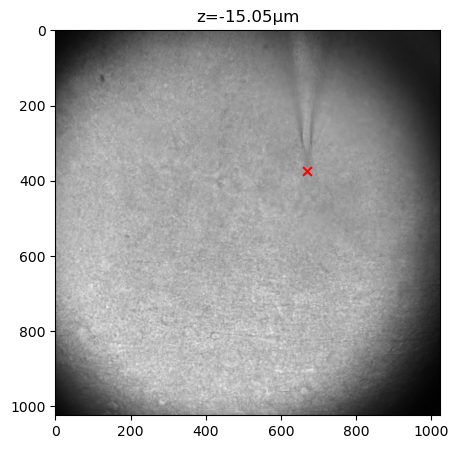

In [34]:
pip_dev = 'PatchPipette2'
pos = log.state(time=img_info['__timestamp__'])[pip_dev]['position']
pip_img_pos = tr.imap(pos)
dz = pos[2] - tr.map((0, 0, 0))[2]

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(img_data, cmap='gray')
ax.scatter(pip_img_pos[1], pip_img_pos[0], color='red', s=40, marker='x')
ax.set_title(f"z={dz*1e6:0.2f}μm")

In [39]:
help(log)

Help on MultiPatchLogData in module acq4.filetypes.MultiPatchLog object:

class MultiPatchLogData(builtins.object)
 |  MultiPatchLogData(filename=None)
 |
 |  Methods defined here:
 |
 |  __getitem__(self, dev: 'str') -> 'dict[str, Any]'
 |
 |  __init__(self, filename=None)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  devices(self) -> 'list[str]'
 |
 |  firstTime(self)
 |
 |  lastTime(self)
 |
 |  process(self, filename) -> 'None'
 |
 |  state(self, time)
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



In [ ]:
import json
rawlog = json.load('[' + open(log_file, 'r').read().rstrip().rstrip(',') + ']')